# Práctica 6 : Detección y comparación de huellas dactilares
## Miembros del equipo:
- Luna Yue Hernández Guerra
- Jorge Lorenzo Lorenzo
---
## Hipotésis Base
La hipótesis base se encuentra explicada en el archivo `Hipotesis_No_IA.md`.

## Desarrollo
### Preprocesamiento de imágenes
Se utilizaron las técnica de preprocesamiento indicadas en la `Hipotesis_No_IA.md` para mejorar la calidad de las imágenes de huellas dactilares antes de aplicar el algoritmo SIFT. Las técnicas incluyeron:

**Buscar y segmentar la ROI**: Se identificó y segmentó la región de interés (ROI) en las imágenes de huellas dactilares para enfocarse en las áreas relevantes.

- `mejor_roi_por_negros` : Esta función se encarga de buscar la zona con más pixeles "negros" donde deducimos que se encuentra el centro de la huella dactilar, para ignorar los bordes blancos

- `recortar_roi` : Recorre todas las carpetas de usuarios y convierte las imágenes a blanco y negro, luego llama a la función `mejor_roi_por_negros` para quedarse con solo la huella.

**Ecualizar y normalizar el histograma**: Se realiza para definir mejor la huella, para ello se usa la función:

- `ecualizar_histograma` : Esta función ejecuta el método de OpenCV `cv2.equalizeHist` para mejorar el contraste de la imagen, conviertiendo los grises oscuros a negros y los grises claros a blancos.

**Aplicar un filtro bilateral**: Se utiliza para reducir el ruido mientras se preservan los bordes, es necesario para mantener los detalles de la huella dactilar. Se utiliza la siguiente función:

- `aplicar_filtro_bilateral` : Esta función aplica un filtro bilateral usando OpenCV para suavizar la imagen mientras mantiene los bordes definidos.

**Aplicar un realce de crestas**: Se utiliza para resaltar las crestas de la huella dactilar, facilitando la detección de características clave. Se utiliza la siguiente función:

- `realzar_crestas` : Esta función utiliza el filtros de Sobel calculando los cambios de intesisdad horizontal y verticial, y los commbina, esto te permite tener una imagen donde las crestas están más definidas.

**Refinar la ROI**: Se utiliza para hacer una limpieza final, se utiliza la función siguiente:

- `refinar_roi` : Realiza un recorte del margen en un 3% para quitar bordes blancos y aplica `cv.morphologyEx` para limpiar la imagen de imperfecciones y también `cv.medianBlur` para eliminar ruido.

#### Código de preprocesamiento


In [2]:
from utils_no_ia import (
    recortar_roi,
    ecualizar_histograma,
    aplicar_filtro_bilateral,
    realzar_crestas,
    refinar_roi,
    comparar_huellas,
    dibujar_curvas_error,
    procesar_y_comparar_test
)

DB_PATH = "data"
OUT_PATH = "output"

print(20*"=")
print("PREPROCESADO")
print(20*"=")

print("Paso 1. Buscar y segmentar la ROI")
recortar_roi(DB_PATH, OUT_PATH, ventana=500, paso=15)  

print("Paso 2. Ecualizar y normalizar el histograma")
ecualizar_histograma(DB_PATH, OUT_PATH)

print("Paso 3. Aplicar un filtro bilateral")
aplicar_filtro_bilateral(DB_PATH, OUT_PATH)

print("Paso 4. Aplicar un realce de crestas")
realzar_crestas(DB_PATH, OUT_PATH)

print("Paso 5. Refinar la ROI eliminando bordes falsos")
refinar_roi(DB_PATH, OUT_PATH)

print(20*"-")
print("Preprocesado finalizado")
print(20*"-")

PREPROCESADO
Paso 1. Buscar y segmentar la ROI
Paso 2. Ecualizar y normalizar el histograma
Paso 3. Aplicar un filtro bilateral
Paso 4. Aplicar un realce de crestas
Paso 5. Refinar la ROI eliminando bordes falsos
--------------------
Preprocesado finalizado
--------------------


### Uso de SIFT para BD de huellas dactilares local
Se implementa el algoritmo SIFT (Scale-Invariant Feature Transform) para extraer características clave de las huellas dactilares preprocesadas y realizar la coincidencia entre ellas. Se realiza comparando las huellas dactilares de un mismo usuario consigo mismo y con las de otros usuarios para evaluar la precisión del algoritmo. Para ello se utilizan la siguiente función:

- `comparar_huellas`: Esta función utiliza SIFT para encontrar encontrar puntos clave, la técncica de para hacer la comparacción es KNN donde compara las huellas entre sí.

Le añadimos también el filtrado geométrico para mejorar la precisión de la comparación, donde no solo se mira si se parecen sino también si siguen la misma geometría. Para esto se utiliza el método `cv.findHomography` que comprueba si ante una rotación los puntos se tienen que seguir pareciendo.

Está función es encargada de guardar las estadísticas necesarias para luego ser mostrado y gráficado, también es lo que utiliza para saber cuantos `inliners` hay en la comparación y saber si son huellas del mismo usuario o no.

#### Código de comparación SIFT

In [3]:
genuinos, impostores = comparar_huellas(DB_PATH, OUT_PATH)


[INFO] Cargando imágenes y generando descriptores SIFT...
[INFO] Se han cargado 20 huellas válidas.

HUELLA A                  | HUELLA B                  | MATCH?   | INLIERS  | RATIO    | RESULTADO                
crd_0811f_01.png          | crd_0811f_01.png          | True     | 1500     | 100.0%   | TP (Auto-Check)
crd_0811f_01.png          | crd_0811s_01.png          | False    | 5        | 33.3%    | FN (No concidio)
crd_0811f_01.png          | crd_0812f_01.png          | False    | 7        | 18.4%    | TN (Correcto)
crd_0811f_01.png          | crd_0812s_01.png          | False    | 6        | 27.3%    | TN (Correcto)
crd_0811f_01.png          | crd_0813f_01.png          | True     | 8        | 30.8%    | FP (Error)
crd_0811f_01.png          | crd_0813s_01.png          | False    | 5        | 29.4%    | TN (Correcto)
crd_0811f_01.png          | crd_0814f_01.png          | True     | 9        | 23.7%    | FP (Error)
crd_0811f_01.png          | crd_0814s_01.png          | False  

### Visualización de los resultados
Se busca comparar realizar una gráfica donde se muestren los 4 casos posibles de comparación de huellas dactilares:

- True Positive (TP): Comparación de huellas del mismo usuario que coinciden correctamente.

- True Negative (TN): Comparación de huellas de diferentes usuarios que no coinciden correctamente.

- False Positive (FP): Comparación de huellas de diferentes usuarios que coinciden incorrectamente.

- False Negative (FN): Comparación de huellas del mismo usuario que no coinciden incorrectamente.

Para ello se ha utilizado la función `dibujar_curvas_error` que utiliza los valores de salida de la función `comparar_huellas` para generar la gráfica que son dos campanadas de Gauss superpuestas, donde se puede ver qué tan bien separa el sistema a los usuarios genuinos(curva roja) de los impostores(curva azul).

#### Código de visualización de resultados

Generando gráficas de error (FAR/FRR)...
[GRAFICA] Generando ventana de gráfico...


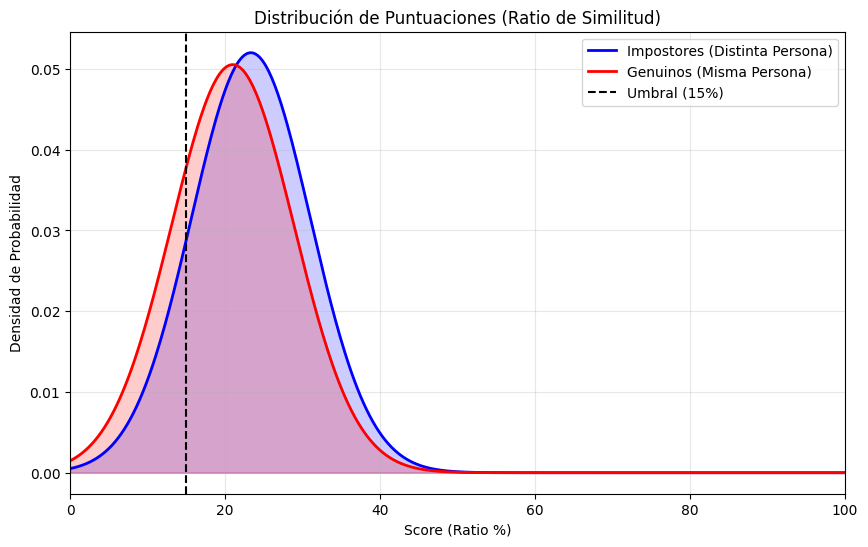

In [4]:
print("Generando gráficas de error (FAR/FRR)...")
dibujar_curvas_error(genuinos, impostores, umbral=15)

**Conclusiones**

Se puede observar como las gráficas se encuentran solapadas, lo que indica que el sistema tiene dificultades para distinguir entre los usuarios genuinos y los impostores. Esto implica que seguramente haya algun proceso del preprocesamiento que esta influyendo al mal funcionamiento de SIFT. Pudiendo ser, la aplicación del Sobel que puede estar eliminando detalles en la huella dactilar.

### Testing
Se van a utilizar un dataset que se va a guardar dentro de la carpeta `test`, donde lo que se busca es comparar las huellas dactilares con la de la base de datos para ver si existe coincidencia o no. Aquí, se busca acercarnos a un caso más realista. Para ello se ha creado la función de `procesar_y_comparar_test` que se encarga de preprocesar las imágenes de test y compararlas con la base de datos utilizando SIFT.

El resultado del SIFT se comparará con toda la base de datos y busca el que tenga mayor número de `inliners`, donde si tiene más de 12 inliners se considerará que es una coincidencia y si tiene más de 8 inliners se considerará una posible coincidencia, en caso contrario se considerará que no hay coincidencia.

#### Código de testing

In [5]:
print(20*"=")
print("FASE DE TEST: Identificando huellas desconocidas")
print(20*"=")

TEST_PATH = "test"
OUT_TEST_PATH = "output/test"
DB_PROCESSED_PATH = OUT_PATH

procesar_y_comparar_test(TEST_PATH, DB_PROCESSED_PATH, OUT_TEST_PATH)

FASE DE TEST: Identificando huellas desconocidas

[TEST] Buscando imágenes en: test
[TEST] Procesando 6 imágenes desconocidas...
  -> Procesada: Huella_p1 copy 2.png
  -> Procesada: Huella_p1 copy 3.png
  -> Procesada: Huella_p1 copy 4.png
  -> Procesada: Huella_p1 copy 5.png
  -> Procesada: Huella_p1.png
  -> Procesada: Huella_p2.png

[AUTH] Iniciando autenticación contra la base de datos...
[AUTH] Comparando contra 10 usuarios registrados.

------------------------------------------------------------
Identificando huella desconocida: Huella_p1 copy 2.png
  >>> IDENTIFICADO: crd_0811f
      (Evidencia muy fuerte: 1500 inliers con crd_0811f_01.png)

------------------------------------------------------------
Identificando huella desconocida: Huella_p1 copy 3.png
  >>> IDENTIFICADO: crd_0811f
      (Evidencia muy fuerte: 1500 inliers con crd_0811f_01.png)

------------------------------------------------------------
Identificando huella desconocida: Huella_p1 copy 4.png
  >>> IDENTIFIC

**Conclusiones**

Se puede observar que da buenos resultados, pero este caso es así porque los datos que se usan son copias de los datos anteriores y esta comparando huellas consigo misma, entonces no son huellas tomadas en condiciones reales.